Dataset:
                                          image_path    video_id  \
0  /kaggle/input/datasets/hafsanaz56/video-proces...  VIDEO_0001   
1  /kaggle/input/datasets/hafsanaz56/video-proces...  VIDEO_0001   
2  /kaggle/input/datasets/hafsanaz56/video-proces...  VIDEO_0001   
3  /kaggle/input/datasets/hafsanaz56/video-proces...  VIDEO_0001   
4  /kaggle/input/datasets/hafsanaz56/video-proces...  VIDEO_0001   

                           original_filename    source  label  frame_number  \
0  REAL_0086_Celeb-DF_YouTube-real_00272.mp4  Celeb-DF      0             1   
1  REAL_0086_Celeb-DF_YouTube-real_00272.mp4  Celeb-DF      0            27   
2  REAL_0086_Celeb-DF_YouTube-real_00272.mp4  Celeb-DF      0            41   
3  REAL_0086_Celeb-DF_YouTube-real_00272.mp4  Celeb-DF      0            54   
4  REAL_0086_Celeb-DF_YouTube-real_00272.mp4  Celeb-DF      0            69   

  split identity_group  
0  test            NaN  
1  test            NaN  
2  test            NaN  
3  test

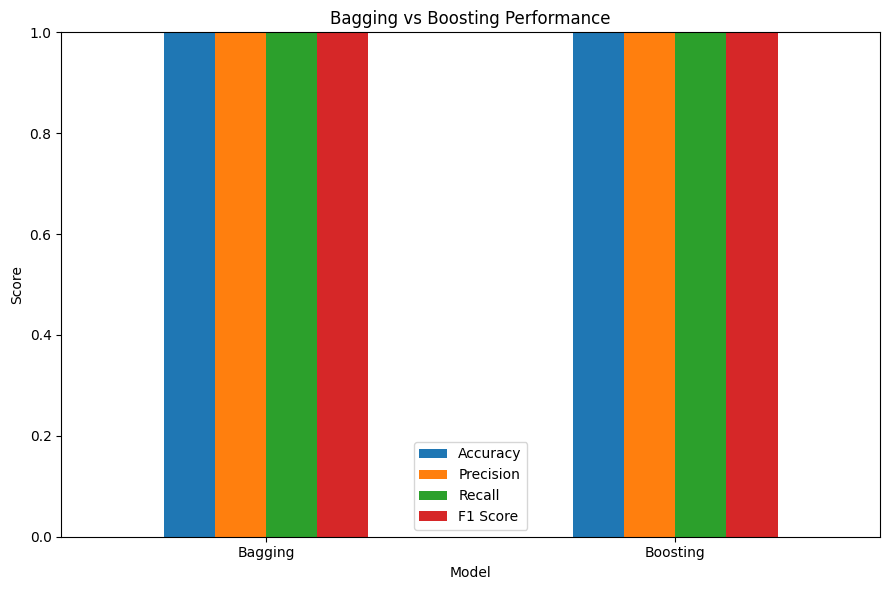

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

df = pd.read_csv("final_clean_face_manifest_split.csv")

print("Dataset:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

columns_to_drop = ["PassengerId", "Name", "Ticket", "Cabin"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

if "Age" in df.columns:
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

for column in df.select_dtypes(include=["object"]).columns:
    df[column] = LabelEncoder().fit_transform(df[column].astype(str))

df = df.dropna()

X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

bagging.fit(X_train, y_train)
boosting.fit(X_train, y_train)

bagging_pred = bagging.predict(X_test)
boosting_pred = boosting.predict(X_test)

bagging_accuracy = accuracy_score(y_test, bagging_pred)
bagging_precision = precision_score(y_test, bagging_pred)
bagging_recall = recall_score(y_test, bagging_pred)
bagging_f1 = f1_score(y_test, bagging_pred)

boosting_accuracy = accuracy_score(y_test, boosting_pred)
boosting_precision = precision_score(y_test, boosting_pred)
boosting_recall = recall_score(y_test, boosting_pred)
boosting_f1 = f1_score(y_test, boosting_pred)

print("\nBAGGING PERFORMANCE")
print("Accuracy:", bagging_accuracy)
print("Precision:", bagging_precision)
print("Recall:", bagging_recall)
print("F1 Score:", bagging_f1)

print("\nBagging Confusion Matrix:")
print(confusion_matrix(y_test, bagging_pred))

print("\nBOOSTING PERFORMANCE")
print("Accuracy:", boosting_accuracy)
print("Precision:", boosting_precision)
print("Recall:", boosting_recall)
print("F1 Score:", boosting_f1)

print("\nBoosting Confusion Matrix:")
print(confusion_matrix(y_test, boosting_pred))

results = pd.DataFrame({
    "Model": ["Bagging", "Boosting"],
    "Accuracy": [bagging_accuracy, boosting_accuracy],
    "Precision": [bagging_precision, boosting_precision],
    "Recall": [bagging_recall, boosting_recall],
    "F1 Score": [bagging_f1, boosting_f1]
})

print("\nMODEL PERFORMANCE COMPARISON")
print(results)

results.set_index("Model").plot(kind="bar", figsize=(9, 6))
plt.title("Bagging vs Boosting Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()